In [1]:
# reikalingi paketai
import torch
import numpy as np
import torchvision
from torchvision import models
from PIL import Image

In [2]:
# ar yra GPU, priskirti device
# ant Apple irenginiu, yra mps, kuris yra butent skirtas masininiam mokymuisi
print(torch.backends.mps.is_available())
device = torch.device('mps')
print(device)

True
mps


In [3]:
import os
import certifi

os.environ['SSL_CERT_FILE'] = certifi.where()

In [4]:
# pasirinkau dėstytojo rekomenduotą resnet pre-trained modelį

model = models.resnet34(weights = models.ResNet34_Weights.DEFAULT).to(device)

In [5]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
transforms = models.ResNet34_Weights.DEFAULT.transforms()


In [7]:
from openimages.download import download_dataset
classes = ["Snake", "Rabbit", "Shark"]
data_dir = "data"


Paleisti download'ą tik jeigu nėra testavimo duomenų.

In [8]:
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

print(f"Downloading images for: {classes}")
try:
    download_dataset(data_dir, classes, limit=1000)
except TypeError:
    print("Download failed.")

KeyboardInterrupt: 

In [10]:
weights = models.ResNet34_Weights.DEFAULT
categories = weights.meta["categories"]

# isprintinti visas klases
# for i, category in enumerate(categories):
#     print(f"{i}: {category}")

In [12]:
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F

# pazymimas dataset'as ir uzkraunamas data loaderis
dataset = datasets.ImageFolder(root=data_dir, transform=transforms)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

results = [] # laikomi rezultatai - modelio spejimai (prediction'ai)
ground_truth = [] # laikoma tiesa - koks yra rezultatas is tikruju

# kadangi modelį reikėtų treniruoti iš naujo, jeigu jis pateiktų atsakymus tik kaip tris klases, vietoje to, kad nereikėtų treniruoti, bus pasirenkamos išfiltruotos klasės
target_classes = {
    0: [330, 331, 332], # triušiai, kiškiai (Rabbit, Hare)
    1: [2, 3, 4], # rykliai (Shark)
    2: list(range(52, 69)) # gyvatės (Snake)
}

all_relevant_classes = [idx for sublist in target_classes.values() for idx in sublist]

# modelis perjungiamas į testavimo režimą
model.to(device)
model.eval()

with torch.no_grad():
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs) # gaunami tūkstantį klasių turintys rezultatai

        # atrenkami kiekvienos pasirinktos klasės rezultatai
        rabbit_scores, _ = torch.max(outputs[:, target_classes[0]], dim=1)
        shark_scores, _ = torch.max(outputs[:, target_classes[1]], dim=1)
        snake_scores, _ = torch.max(outputs[:, target_classes[2]], dim=1)

        # sukuriamas trijų klasių logit
        three_logits = torch.stack([rabbit_scores, shark_scores, snake_scores],dim=1)

        # rezultatai perkuriami taip, jog tai butu procentalines israiskos nuo 0 iki 1
        predictions = F.softmax(three_logits, dim=1)

        # rezultatų pakeitimas iš pytorch elementų į numpy
        results.extend(predictions.cpu().numpy())
        ground_truth.extend(labels.numpy())

print(f"Processed {len(results)} images.")
print(f"Evaluation mapped to {len(target_classes)} categories.")

Processed 1254 images.
Evaluation mapped to 3 categories.


In [30]:
# keičiamos reikšmės iš numpy į paprastus tipus paprastesniam atvaizdavimui
results_standard = [[float(val)for val in res] for res in results]
ground_truth_standard = [int(gt) for gt in ground_truth]

print(results_standard)
print(ground_truth_standard)

[[0.9999901056289673, 9.090356911656272e-07, 8.906677066988777e-06], [0.9999077320098877, 3.890720836352557e-05, 5.334712113835849e-05], [0.9999998807907104, 5.177461126493199e-09, 1.7793568929391768e-07], [0.9958815574645996, 0.002123307203873992, 0.001995198195800185], [0.9999637603759766, 3.7804829844390042e-06, 3.2368105166824535e-05], [0.9996579885482788, 9.260910616148976e-08, 0.00034194960608147085], [0.9999775886535645, 1.719379361020401e-05, 5.195168796490179e-06], [0.9999988079071045, 1.121411496995961e-08, 1.1836099247375387e-06], [0.9991834759712219, 2.4551006845285883e-06, 0.000813967315480113], [0.9999998807907104, 6.912988403939835e-09, 1.197610544068084e-07], [0.9999939203262329, 1.1918626796614262e-06, 4.894061476079514e-06], [0.999996542930603, 5.077073339521121e-08, 3.472636535661877e-06], [0.9999998807907104, 4.008844367575648e-09, 7.481030905864827e-08], [0.9999992847442627, 1.390973780601712e-09, 7.486868867090379e-07], [0.9977474808692932, 0.000668373191729188, 0

In [31]:
def calculate_confusion_matrix(ground_truth, predictions, target_index, threshold = 0.5):
    tp = tn = fp = fn = 0

    for gt, pred in zip(ground_truth, predictions): # zip - paima du sąrašus, ir jų indeksus sujungia ir padaro porą

        # atrenkamas didžiausią tikimybę turimas rezultatas ir jo indeksas
        max_pred = max(pred)
        pred_index = pred.index(max_pred)

        # pasižiūrima, ar tikimybė yra pakankamai didelė, jog būtų laikoma kaip teigiamas rezultatas
        predicted_result = (pred_index == target_index) and (max_pred >= threshold)
        actual_result = (gt == target_index)

        if predicted_result and actual_result:
            tp += 1
        elif predicted_result and not actual_result:
            fp += 1
        elif not predicted_result and actual_result:
            fn += 1
        else:
            tn += 1

    return {"TP": tp, "TN": tn, "FP": fp, "FN": fn}

In [43]:
def calculate_metrics(confusion_matrix):
    tp = confusion_matrix['TP']
    fp = confusion_matrix['FP']
    tn = confusion_matrix['TN']
    fn = confusion_matrix['FN']

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    f1 = 2 * (recall * precision) / (recall + precision)

    return {
      'Accuracy': float(accuracy),
      'Recall': float(recall),
      'Precision': float(precision),
      'F1': float(f1),
    }


In [44]:
# kiekvienai klasei apskaičiuojamas confusion matrix ir statistikos
for i, name in enumerate(classes):
    matrix = calculate_confusion_matrix(ground_truth_standard, results_standard, i, threshold=0.5)
    all_matrixes.append(matrix)
    print(f"--- {classes[i]} ---")
    print(f"TP: {matrix['TP']}, TN: {matrix['TN']}, FP: {matrix['FP']}, FN: {matrix['FN']}")
    metrics = calculate_metrics(matrix)
    all_metrics.append(metrics)
    print(f"Accuracy: {metrics['Accuracy']}, Precision: {metrics['Precision']}, Recall: {metrics['Recall']}, F1: {metrics['F1']}")


--- Snake ---
TP: 336, TN: 907, FP: 2, FN: 9
Accuracy: 0.9912280701754386, Precision: 0.9940828402366864, Recall: 0.9739130434782609, F1: 0.9838945827232797
--- Rabbit ---
TP: 486, TN: 755, FP: 3, FN: 10
Accuracy: 0.9896331738437002, Precision: 0.9938650306748467, Recall: 0.9798387096774194, F1: 0.9868020304568528
--- Shark ---
TP: 412, TN: 829, FP: 12, FN: 1
Accuracy: 0.9896331738437002, Precision: 0.9716981132075472, Recall: 0.9975786924939467, F1: 0.984468339307049


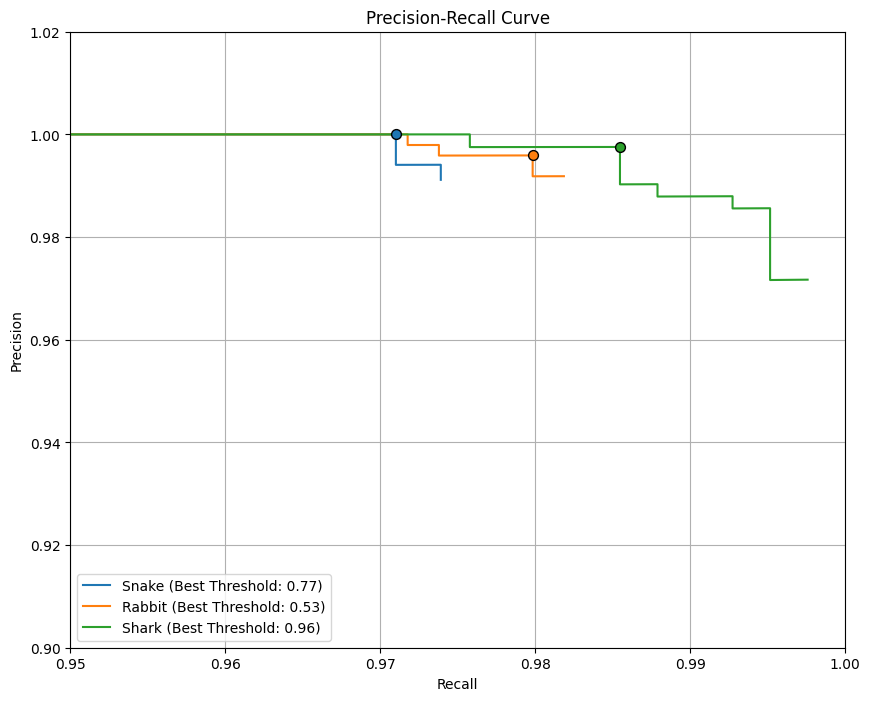

In [45]:
import matplotlib.pyplot as plt

threshold_steps = [i / 1000 for i in range(1001)]

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(classes):
    precision_points = []
    recall_points = []
    best_metrics = {'F1': -1.0}

    for t in threshold_steps:
        # Get confusion matrix for the specific threshold
        matrix = calculate_confusion_matrix(ground_truth_standard, results_standard, i, threshold=t)
        # Use the reusable metrics function
        metrics = calculate_metrics(matrix)

        precision_points.append(metrics['Precision'])
        recall_points.append(metrics['Recall'])

        if metrics['F1'] >= best_metrics['F1']:
            best_metrics = metrics.copy()
            best_metrics['t'] = t

    # Plot the curve for the current class
    line, = plt.plot(recall_points, precision_points, label=f"{class_name} (Best Threshold: {best_metrics['t']:.2f})")

    # Use best_f1 dictionary for the point coordinates
    plt.scatter(best_metrics['Recall'], best_metrics['Precision'], color=line.get_color(), s=50, edgecolors='black', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.xlim([0.95, 1.0])
plt.ylim([0.9, 1.02])
plt.show()